# Isoprene Aerosol Studies

---
Last modified: March 6th, 2025 (JY)

This notebook uses a modified version of vSmartMOM with functions specifically for isoprene to calculate radiances with different amounts of aerosols.

This notebook is coded in Julia.

---

###  To modify YAML files in Julia:

#### Scattering Parameters
- parameters.scattering_params.rt_aerosols[1].aerosol.size_distribution.μ
- parameters.scattering_params.rt_aerosols[1].aerosol.size_distribution.σ
- parameters.scattering_params.rt_aerosols[1].aerosol.nᵣ
- parameters.scattering_params.rt_aerosols[1].aerosol.nᵢ
- parameters.scattering_params.rt_aerosols[1].τ_ref
- parameters.scattering_params.rt_aerosols[1].profile.μ
- parameters.scattering_params.rt_aerosols[1].profile.σ
- parameters.scattering_params.λ_ref

#### Absorption Parameters 
- parameters.absorption_params.molecules[1]
- parameters.absorption_params.vmr["ISOP"]

#### Overall Parameters 
- parameters.sza
- parameters.vza
- parameters.vaz
- parameters.spec_bands[1]
- parameters.brdf[1]


---

In [1]:
# Activate Julia packages
using Pkg;
Pkg.activate("../"); # Activates the vSmartMOM.jl Project.toml file
Pkg.instantiate();

# Using local module, since the current version of vSmartMOM does not support isoprene (not a HITRAN line list species)
include("../src/vSmartMOM.jl");
include("helper_functions.jl");

# Other imports
using Revise, PlotlyBase, Plots, LinearAlgebra, NCDatasets, Format, LaTeXStrings, .vSmartMOM;
default(fontfamily="Computer Modern");

  Activating project at `~/Documents/Radiative_Transfer/vSmartMOM.jl`


### We now need to specify parameters for the model.

I have downloaded 10 days (2019-07-01 to 2019-07-10) in the MERRA2 folder. You will need to manually download more days if you would like different conditions.

In [3]:
# Parameters for atmospheric profile
date = "20190701"
startTime = "06z"
lat = 2.
lon = 100.

merra2_profile = retrieve_merra2_conditions(date, startTime, lat, lon);

pressures = merra2_profile.p_levels ./ 100; # Convert to hPa
pressures_midpoints = merra2_profile.p ./ 100; # Convert to hPa
temperatures = merra2_profile.T;
specific_humidity = merra2_profile.q .* 1000; # Convert from kg/kg (in MERRA2) to g/kg;

current_profile = specific_humidity ./ 1000 .* 1e-7; # Get current isoprene vertical profile
total_column = merra2_profile.vcd_dry .* current_profile; # Multiply by vertical column density
total_column = sum(total_column) # Sum for the total column
println("The total column is $(total_column) molec cm-2.")

mean_vmr = total_column / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr * 1e9) ppbv.")

current_profile_x5 = specific_humidity ./ 1000 .* 1e-7 .* 5; # Get current isoprene vertical profile
total_column_x5 = merra2_profile.vcd_dry .* current_profile_x5; # Multiply by vertical column density
total_column_x5 = sum(total_column_x5) # Sum for the total column
println("The total column is $(total_column_x5) molec cm-2.")

mean_vmr_x5 = total_column_x5 / sum(merra2_profile.vcd_dry)
println("The equivalent constant VMR is $(mean_vmr_x5 * 1e9) ppbv.")

ds["T"] = T (576 × 361 × 72 × 4)
  Datatype:    Union{Missing, Float32} (Float32)
  Dimensions:  lon × lat × lev × time
  Attributes:
   long_name            = Air temperature
   units                = K
   _FillValue           = 1.0e15
   missing_value        = 1.0e15
   fmissing_value       = 1.0e15
   scale_factor         = 1.0
   add_offset           = 0.0
   standard_name        = air_temperature
   vmax                 = 1.0e15
   vmin                 = -1.0e15
   valid_range          = Float32[-1.0f15, 1.0f15]

The total column is 1.0351391432445896e16 molec cm-2.
The equivalent constant VMR is 0.49235111030987266 ppbv.
The total column is 5.175695716222948e16 molec cm-2.
The equivalent constant VMR is 2.4617555515493637 ppbv.


In [15]:
import InstrumentOperator: FTSInstrument, create_instrument_kernel, FixedKernelInstrument, conv_spectra

ν_min = 890.
ν_max = 910.
Δν = 0.01
ν = ν_min:Δν:ν_max

x = -5:Δν:5
fov = 16.8 # mrads
mopd = 0.8 # cm
FTS = FTSInstrument(0.8, fov * 1e-3, 0.)
unapodized_fts = create_instrument_kernel(FTS, x, 900.0)

p = plot(x, unapodized_fts.parent,label="CrIS Unapodized FTS Lineshape",lw=2, dpi = 300, title = "CrIS Unapodized FTS Instrument Line Shape \n(FOV = 16.8 mrads, MOPD = 0.8 cm)")
ylabel!("Channel Response Function")
xlabel!(L"$\sigma$ $[cm^{-1}]$")
savefig(p, "Figures/unapodized_instrument_kernel.png")

margin = 0
sampling = 0.625
cris_instrument_kernel = FixedKernelInstrument(unapodized_fts, collect(ν_min+margin:sampling:ν_max-margin))

(Θ, β) = (0.12700800000000004, 0.0)


┌ Info: Center of OffsetArrays is 
│   minimum(abs.(grid_x)) = 0.0
└ @ InstrumentOperator /Users/jamesyoon/.julia/packages/InstrumentOperator/JJWCH/src/prepare_ils.jl:39


FixedKernelInstrument{Float64}([-0.0001938027449118005, -0.00022515990131574464, -0.0002560745521885616, -0.0002864668905839412, -0.0003162580989748737, -0.0003453705508071965, -0.00037372800988458884, -0.00040125582708002165, -0.0004278811338732687, -0.00045353303222005073  …  -0.00011292824838757243, -9.056541516724512e-5, -7.058344327000462e-5, -5.30230478386403e-5, -3.791869420702852e-5, -2.529853680148194e-5, -1.5184374041206004e-5, -7.5916192866803565e-6, -2.5292878448332848e-6, -1.463672932855431e-18], [890.0, 890.625, 891.25, 891.875, 892.5, 893.125, 893.75, 894.375, 895.0, 895.625  …  904.375, 905.0, 905.625, 906.25, 906.875, 907.5, 908.125, 908.75, 909.375, 910.0])

# Part I: Aerosols versus No Aerosols

Albedo is 0 to correspond with very little surface reflectance in the thermal IR.

In [6]:
# Aerosols, ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
aerosols_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.absorption_params.vmr["ISOP"] = specific_humidity ./ 1000 * 1e-7 * 5;

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
no_aerosols_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Aerosols, No ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol

parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.absorption_params.vmr["ISOP"] = 0.

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
aerosols_no_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, No ISOP
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.absorption_params.vmr["H2O"] = specific_humidity ./ 1000 * 28.96/18.02; # convert to kg/kg from g/kg, then mol/mol
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params = nothing
parameters.absorption_params.vmr["ISOP"] = 0.

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
no_aerosols_no_ISOP = vSmartMOM.CoreRT.rt_run(model); # Run the model

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr [1.4030530337549863e-12, 1.711165396045544e-12, 1.8979955029863046e-12, 2.0519391910056583e-12, 2.083041636069538e-12, 2.1113983166287653e-12, 2.1232958715700076e-12, 2.1323176042642443e-12, 2.1326179648895046e-12, 2.1336613826861138e-12, 2.1292639758030418e-12, 2.108552507706918e-12, 2.080265403492376e-12, 2.0373288407427026e-12, 1.9899059680028582e-12, 1.9327096651977627e-12, 1.884506218630122e-12, 1.8456980797054712e-12, 1.797914592316374e-12, 1.7476361335866386e-12, 1.6859436300364906e-12, 1.6254640513579942e-12, 1.550242359371623e-12, 1.4844666793578653e-12, 1.4295778782980049e-12, 1.3894941730541175e-12, 1.3609560483018867e-12, 1.350213892692409e-12, 1.3419920605883818e-12, 1.325305106547603e-12, 1.2907921700389124e-12, 1.2448508641682565e-12, 1.1840575098176486e-12, 1.144

Progress: 100%|█████████████████████████████████████████| Time: 0:00:49


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:09
┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


Fourier Moment: 2/2


Looping over layers ... 100%|████████████████████████████| Time: 0:00:09


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               94.6s /  93.6%            145GiB /  98.2%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    58.3s   65.8%   14.6s   50.3GiB   35.4%  12.6GiB
RT Kernel                       216    29.0s   32.8%   134ms   87.9GiB   61.9%   417MiB
  doubling                      216    21.6s   24.4%   100ms   70.9GiB   49.9%   336MiB
    Batch Inv Doubling        1.50k    10.8s   12.2%  7.20ms   29.7GiB   20.9%  20.2MiB
  interaction                   213    5.48s    6.2%  25.7ms   16.9GiB   11.9%  81.0MiB
    interaction inv1 bla       

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [54]:
function plot_multiple_zenith_angles(spectrum_1, spectrum_2, index)
    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);

    if index == 1
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "No aerosols", lw = 1, dpi = 300)
    else
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 1, dpi = 300)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);

    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "Aerosols", lw = 1)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 1)
    end
    
    if index >= 4
        xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
    end

    if index == 1 || index == 4
        ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
    end
    title!("VZA = $(parameters.vza[index])")
    return p
end

function plot_multiple_zenith_angles_difference(spectrum_1, spectrum_2, index)
    convol_spectrum_1 = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);
    convol_spectrum_2 = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);

    p = plot(cris_instrument_kernel.ν_out, convol_spectrum_2 - convol_spectrum_1, label = "No aerosols", lw = 1, dpi = 300)
    
    xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
    ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
    title!("VZA = $(parameters.vza[index])")

    return p
end

plot_multiple_zenith_angles_difference (generic function with 1 method)

In [58]:
p1 = plot_multiple_zenith_angles(no_aerosols_ISOP, aerosols_ISOP, 1)
p2 = plot_multiple_zenith_angles(no_aerosols_ISOP, aerosols_ISOP, 2)
p3 = plot_multiple_zenith_angles(no_aerosols_ISOP, aerosols_ISOP, 3)
p4 = plot_multiple_zenith_angles(no_aerosols_ISOP, aerosols_ISOP, 4)
p5 = plot_multiple_zenith_angles(no_aerosols_ISOP, aerosols_ISOP, 5)
p6 = plot_multiple_zenith_angles(no_aerosols_ISOP, aerosols_ISOP, 6)

p = plot(p1, p2, p3, p4, p5, p6)
savefig(p, "figures/VZA_dependence_aerosols.png");

In [64]:
p = plot(cris_instrument_kernel.ν_out, conv_spectra(cris_instrument_kernel, ν, no_aerosols_no_ISOP[1][1,1,:]), label = "Clear retrieval, no ISOP", color = "cornflowerblue", linestyle =:dash, dpi = 600)
plot!(cris_instrument_kernel.ν_out,conv_spectra(cris_instrument_kernel, ν, no_aerosols_ISOP[1][1,1,:]), label = "Clear retrieval", color = "cornflowerblue")

plot!(cris_instrument_kernel.ν_out,conv_spectra(cris_instrument_kernel, ν, aerosols_no_ISOP[1][1,1,:]), label = "Cloud with tau ~ 2, no ISOP", color = "gray", linestyle=:dash)
plot!(cris_instrument_kernel.ν_out,conv_spectra(cris_instrument_kernel, ν, aerosols_ISOP[1][1,1,:]), label = "Cloud with tau ~ 2", lw = 2, color = "gray")

title!(L"Cloud Sensitivity Studies (900 hPa, $\tau$ = 2, VZA = 0)")
xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
savefig(p, "figures/cloud_effects.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/cloud_effects.png"

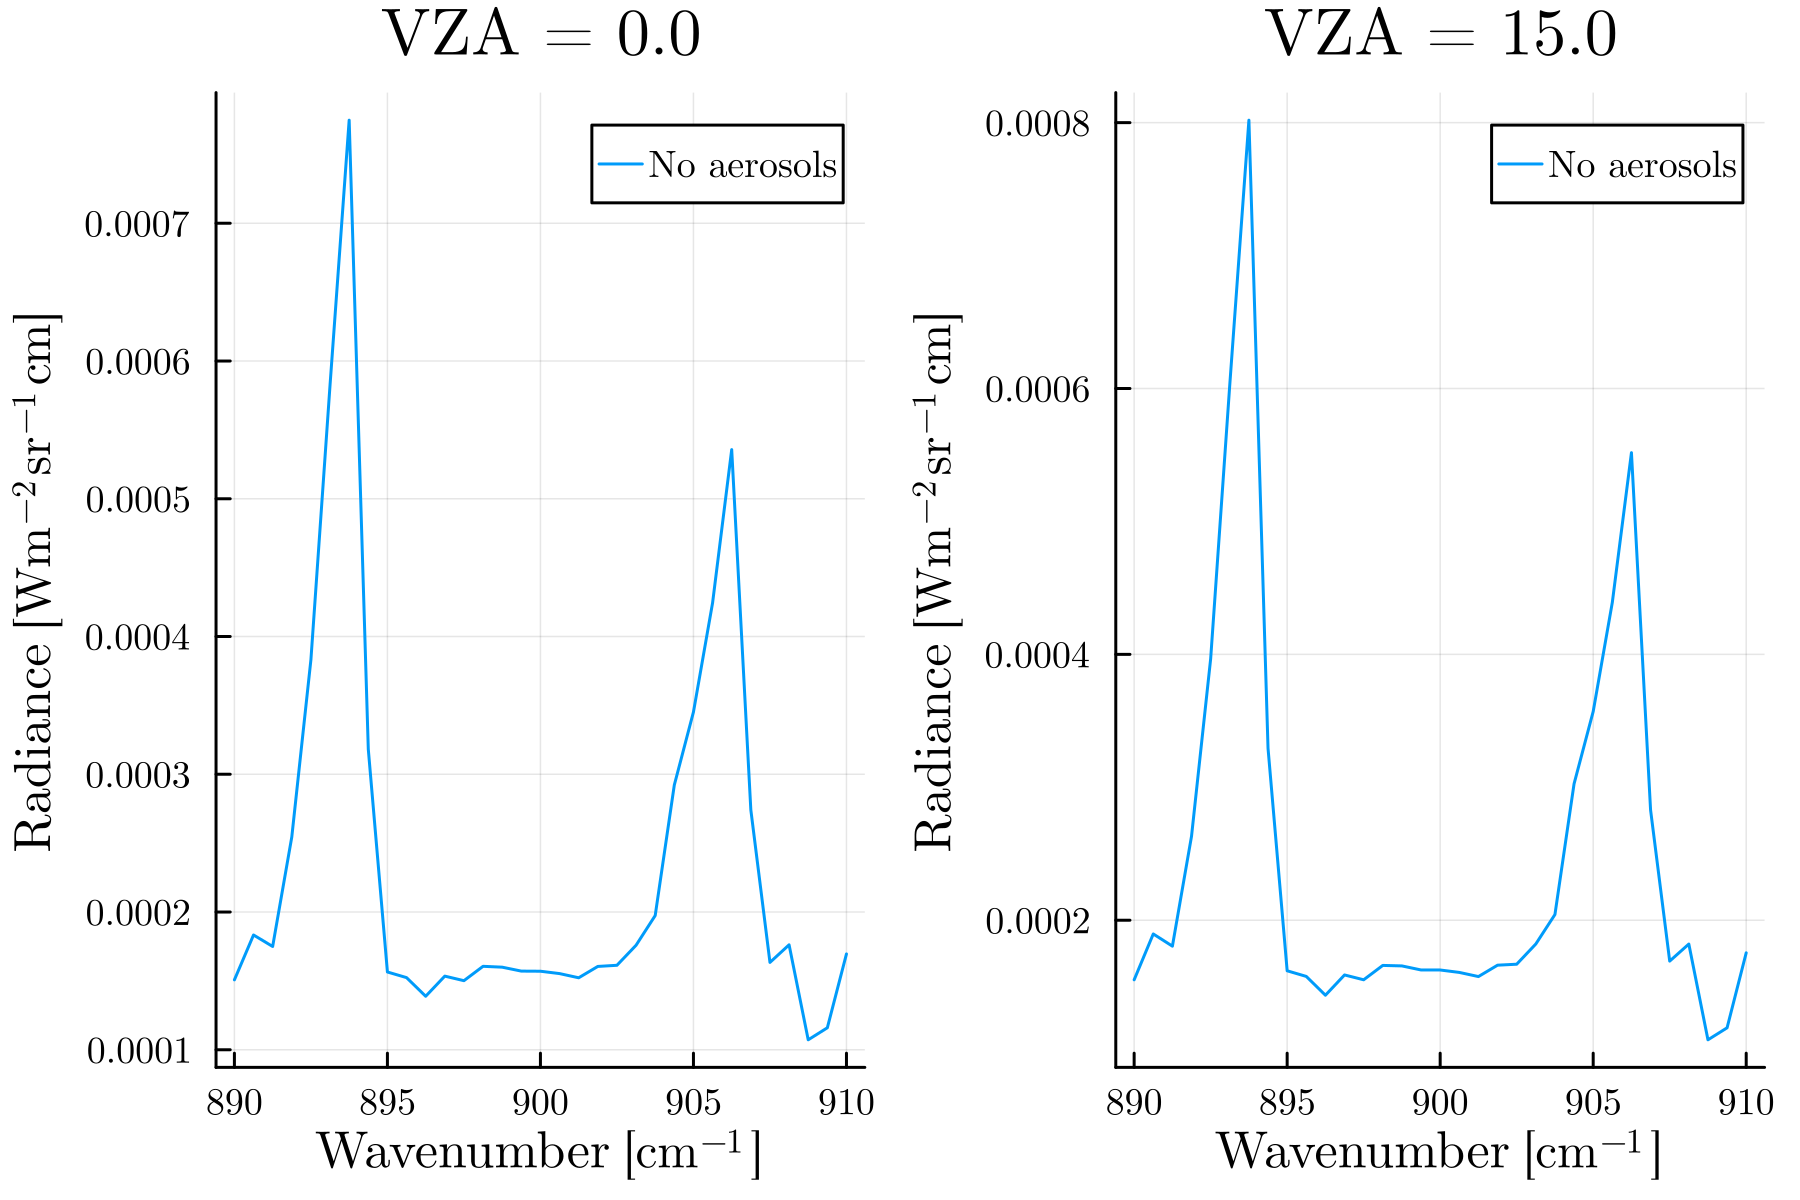

In [70]:
p1 = plot_multiple_zenith_angles_difference(no_aerosols_ISOP, no_aerosols_no_ISOP, 1)
p2 = plot_multiple_zenith_angles_difference(no_aerosols_ISOP, no_aerosols_no_ISOP, 2)
p = plot(p1, p2)

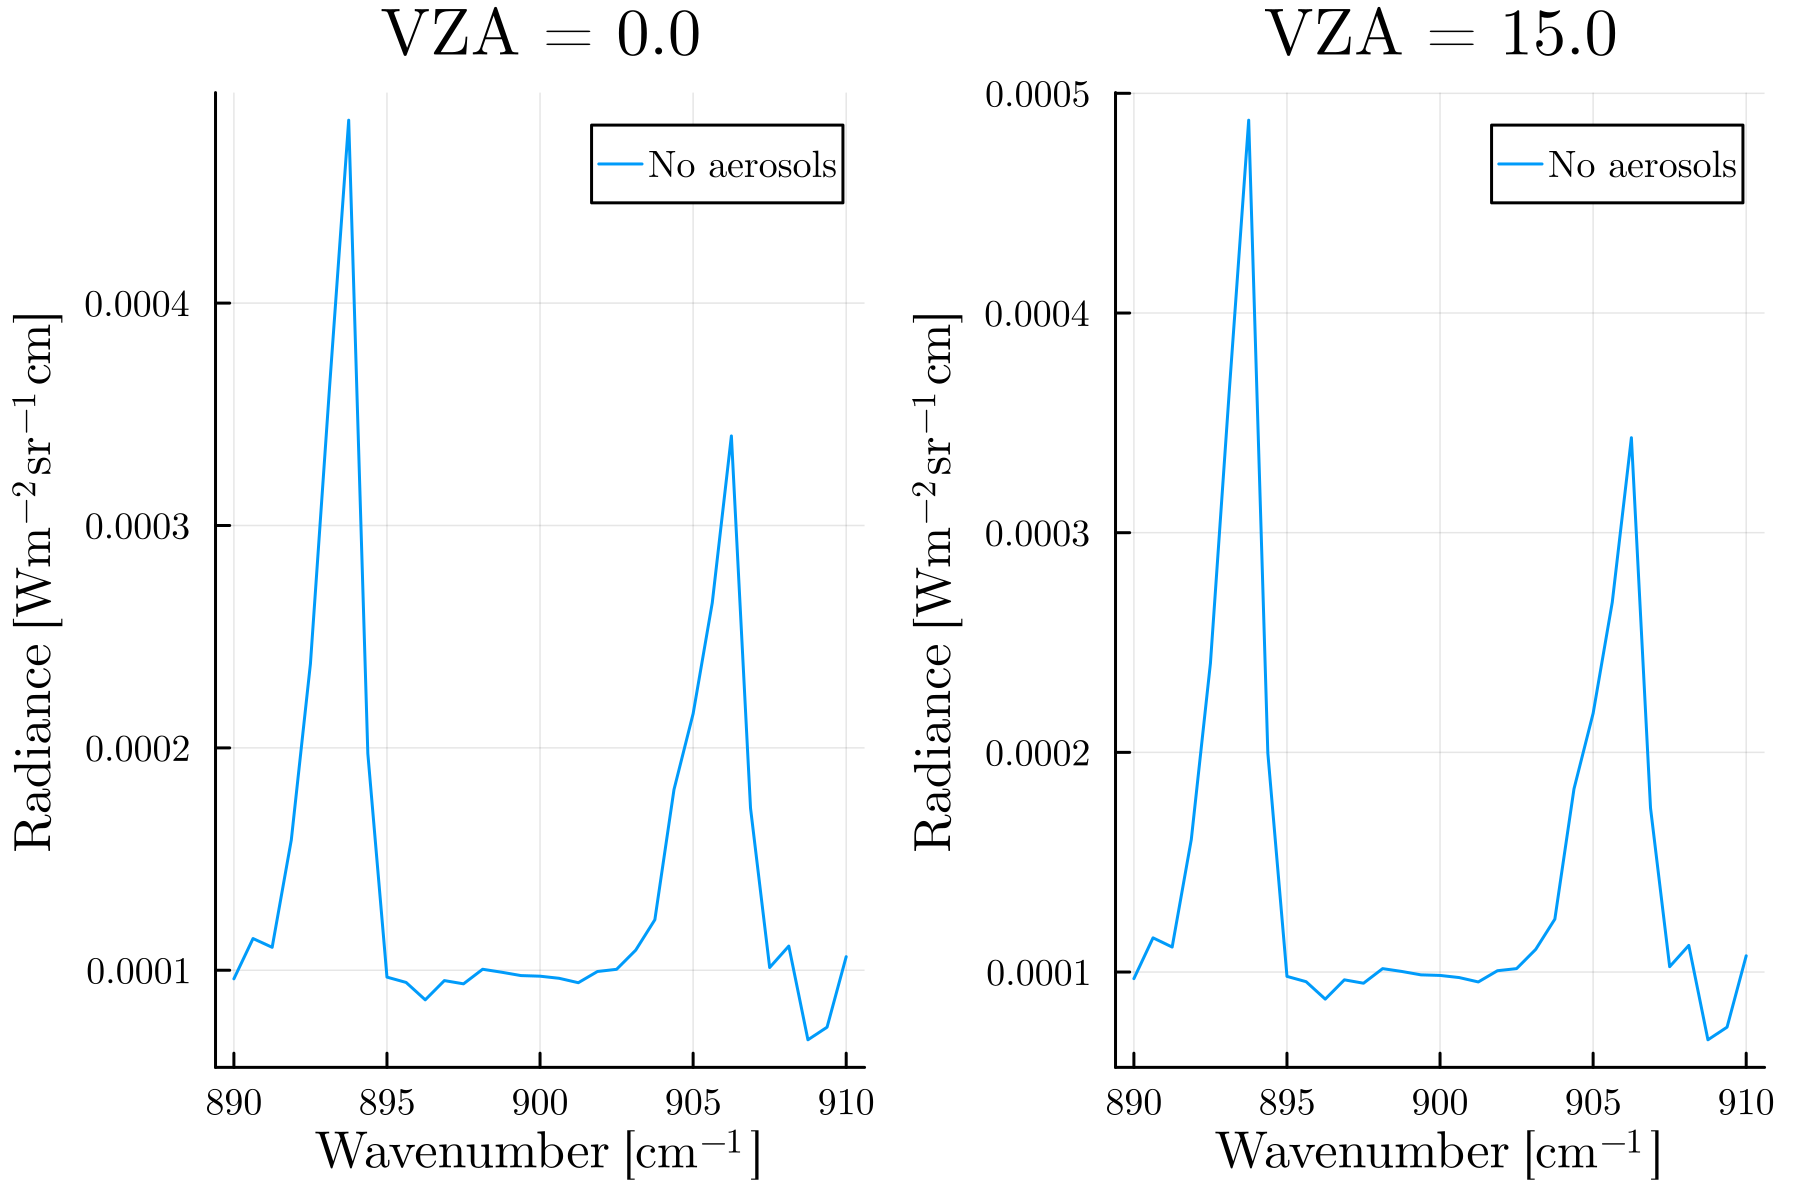

In [71]:
p1 = plot_multiple_zenith_angles_difference(aerosols_ISOP, aerosols_no_ISOP, 1)
p2 = plot_multiple_zenith_angles_difference(aerosols_ISOP, aerosols_no_ISOP, 2)
p = plot(p1, p2)

# Part II: Albedo Sensitivity

In [72]:
# No aerosols, albedo = 0 
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_1 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, albedo = 0.1 
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.1)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_2 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# No aerosols, albedo = 0.3
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.3)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
increasing_albedo_3 = vSmartMOM.CoreRT.rt_run(model); # Run the model

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr 3.0e-9 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:50


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:02


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:03


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               73.1s /  91.9%           73.5GiB /  96.6%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    58.8s   87.5%   14.7s   50.3GiB   70.9%  12.6GiB
RT Kernel                       216    7.89s   11.7%  36.5ms   17.0GiB   23.9%  80.4MiB
  interaction                   213    5.76s    8.6%  27.0ms   16.9GiB   23.8%  81.0MiB
    interaction inv2            213    1.55s    2.3%  7.30ms   4.21GiB    5.9%  20.2MiB
    interaction inv1 bla        213    1.46s    2.2%  6.87ms   4.21GiB    5.9%  20.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [90]:
function plot_multiple_zenith_angles(spectrum_1, spectrum_2, spectrum_3, index)
    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);

    if index == 1
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "Albedo = 0", lw = 2, dpi = 600)
    else
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2, dpi = 600)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);
    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "Albedo = 0.1", lw = 2)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_3[1][index,1,:]);
    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "Albedo = 0.3", lw = 2)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2)
    end

    title!("VZA = $(parameters.vza[index])")

    if index >= 3
        xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
    end

    if mod(index - 1, 3) == 0
        ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
    end
    return p
end

plot_multiple_zenith_angles (generic function with 2 methods)

In [92]:
p1 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 1)
p2 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 2)
p3 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 3)
p4 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 4)
p5 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 5)
p6 = plot_multiple_zenith_angles(increasing_albedo_1, increasing_albedo_2, increasing_albedo_3, 6)

p = plot(p1, p2, p3, p4, p5, p6, size = (900, 600), left_margin = 4Plots.mm)
savefig(p, "figures/albedo_effects_on_absorption.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/albedo_effects_on_absorption.png"

# Part III: Cloud Optical Depth Sensitivity

In [94]:
# No aerosols, albedo = 0
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params = nothing

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
control = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr 3.0e-9 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:50


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:02


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:02


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:               73.2s /  91.4%           73.4GiB /  96.6%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    59.1s   88.3%   14.8s   50.3GiB   70.9%  12.6GiB
RT Kernel                       216    7.50s   11.2%  34.7ms   17.0GiB   23.9%  80.4MiB
  interaction                   213    5.42s    8.1%  25.4ms   16.9GiB   23.8%  81.0MiB
    interaction inv2            213    1.77s    2.7%  8.33ms   4.21GiB    5.9%  20.2MiB
    interaction inv1 bla        213    1.45s    2.2%  6.80ms   4.21GiB    5.9%  20.2MiB
  elemental                    

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [93]:
# Aerosols, albedo = 0, tau = 15.1
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params.rt_aerosols[1].τ_ref = 2

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
optical_depth_1 = vSmartMOM.CoreRT.rt_run(model); # Run the model

# Aerosols, albedo = 0, tau = 2
parameters = vSmartMOM.CoreRT.parameters_from_yaml("yaml_files/scattering_studies.yaml");
parameters.T = temperatures;
parameters.p = pressures;
parameters.q = specific_humidity;
parameters.brdf[1] = vSmartMOM.LambertianSurfaceScalar(0.)
parameters.scattering_params.rt_aerosols[1].τ_ref = 15.1

model = vSmartMOM.CoreRT.model_from_parameters(parameters); # Create model from the YAML file
optical_depth_2 = vSmartMOM.CoreRT.rt_run(model); # Run the model

(params.absorption_params.molecules[i_band])[molec_i] = "CO2"
Computing profile for CO2 with vmr [0.000385, 0.0003850001145941607, 0.00038500025384879586, 0.0003850004219538966, 0.00038500063276675423, 0.0003850009038702479, 0.000385001258001536, 0.0003850017206489304, 0.00038500232154135714, 0.0003850030974095716, 0.00038500409331857524, 0.00038500536414239197, 0.0003850069761741751, 0.00038500900888806304, 0.00038501156012778464, 0.0003850147473088956, 0.00038501870742051154, 0.00038502360124806107, 0.0003850296159776502, 0.0003850369679764387, 0.0003850459051605253, 0.000385056709469902, 0.0003850696986940517, 0.00038508522766744486, 0.0003851036892370286, 0.0003851256512297746, 0.00038515180192201363, 0.0003851828392742149, 0.00038521955635660994, 0.0003852628507344564, 0.0003853137345804603, 0.00038537334173067056, 0.0003854431780424102, 0.0003855250219831911, 0.00038562073333894034, 0.00038573242175436576, 0.0003858624750428068, 0.0003860146818191252, 0.0003861937480754068, 0.000

┌ Info: Warning, make sure that the VMR is interpolated correctly! Right now, it might be tricky
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/atmo_prof.jl:79


Progress: 100%|█████████████████████████████████████████| Time: 0:00:07


(params.absorption_params.molecules[i_band])[molec_i] = "O2"
Computing profile for O2 with vmr 0.21 for band #1
(params.absorption_params.molecules[i_band])[molec_i] = "ISOP"
Computing profile for ISOP with vmr 3.0e-9 for band #1


Progress: 100%|█████████████████████████████████████████| Time: 0:00:50


...

Looping over layers ... 100%|████████████████████████████| Time: 0:00:12


Fourier Moment: 2/2


┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=1
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63
Looping over layers ... 100%|████████████████████████████| Time: 0:00:13


───────────────────────────────────────────────────────────────────────────────────────
                                              Time                    Allocations      
                                     ───────────────────────   ────────────────────────
          Tot / % measured:                105s /  94.3%            174GiB /  98.5%    

Section                      ncalls     time    %tot     avg     alloc    %tot      avg
───────────────────────────────────────────────────────────────────────────────────────
Absorption Coeff                  4    60.1s   60.9%   15.0s   50.3GiB   29.4%  12.6GiB
RT Kernel                       216    37.8s   38.3%   175ms    117GiB   68.4%   555MiB
  doubling                      216    30.7s   31.1%   142ms    100GiB   58.5%   475MiB
    Batch Inv Doubling        2.13k    15.3s   15.6%  7.19ms   42.2GiB   24.6%  20.2MiB
  interaction                   213    5.17s    5.2%  24.3ms   16.9GiB    9.8%  81.0MiB
    interaction inv2           

┌ Info: Radiance Δ range in %: from 0.0 to 0.0 for m=2
└ @ Main.vSmartMOM.CoreRT /Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/src/CoreRT/tools/postprocessing_vza.jl:63


In [100]:
function plot_multiple_zenith_angles(spectrum_1, spectrum_2, spectrum_3, index)
    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_1[1][index,1,:]);

    if index == 1
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = L"\tau = 0", lw = 2, dpi = 600)
    else
        p = plot(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2, dpi = 600)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_2[1][index,1,:]);
    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = L"\tau = 2", lw = 2)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2)
    end

    convol_spectrum = conv_spectra(cris_instrument_kernel, ν, spectrum_3[1][index,1,:]);
    if index == 1
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = L"\tau = 15.1", lw = 2)
    else
        plot!(cris_instrument_kernel.ν_out, convol_spectrum, label = "", lw = 2)
    end

    title!("VZA = $(parameters.vza[index])")

    if index >= 3
        xlabel!(L"Wavenumber $\mathrm{[cm^{-1}]}$")
    end

    if mod(index - 1, 3) == 0
        ylabel!(L"Radiance $\mathrm{[W m^{-2} sr^{-1} cm]}$")
    end
    return p
end

plot_multiple_zenith_angles (generic function with 2 methods)

In [103]:
p1 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 1)
p2 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 2)
p3 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 3)
p4 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 4)
p5 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 5)
p6 = plot_multiple_zenith_angles(control, optical_depth_1, optical_depth_2, 6)

p = plot(p1, p2, p3, p4, p5, p6, size = (900,600), left_margin = 4Plots.mm)
savefig(p, "figures/cloud_optical_depth_effects.png")

"/Users/jamesyoon/Documents/Radiative_Transfer/vSmartMOM.jl/isoprene_scripts/figures/cloud_optical_depth_effects.png"